Applied pressure offset: -0.047811485319516504 bar
CA10 = 3.0 deg
CA50 = 13.5 deg
CA90 = 26.6 deg
IMEP = 7.267961357791595 bar
Analysis results saved to analysis_results.txt


C:\Users\tim\AppData\Local\Temp\ipykernel_8664\3859281595.py:86: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_path, delim_whitespace=True, comment="#")


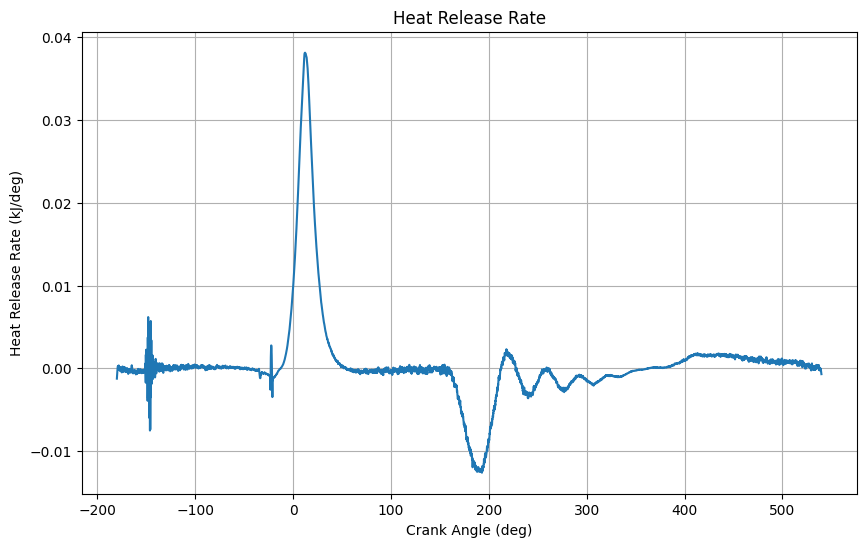

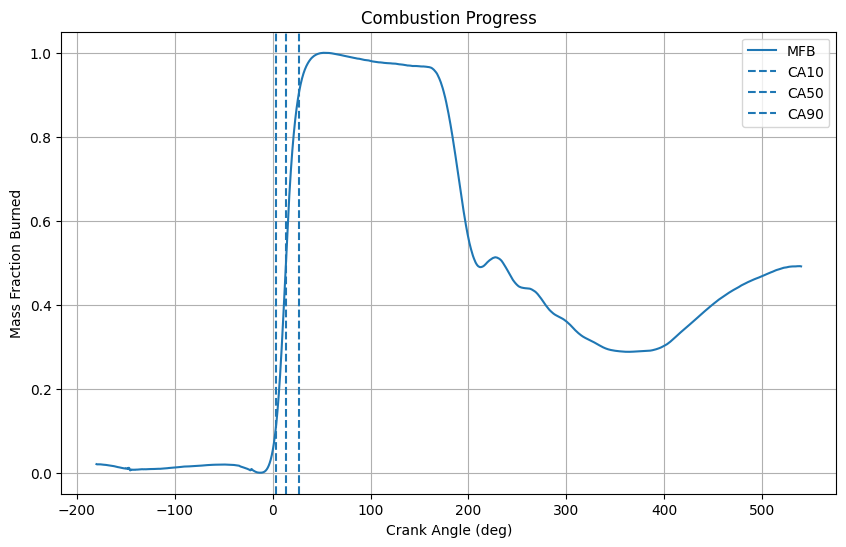

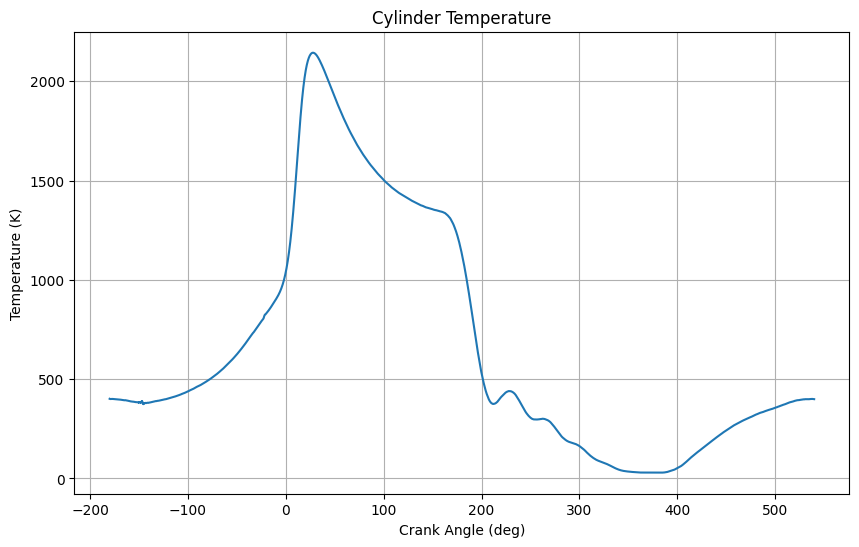

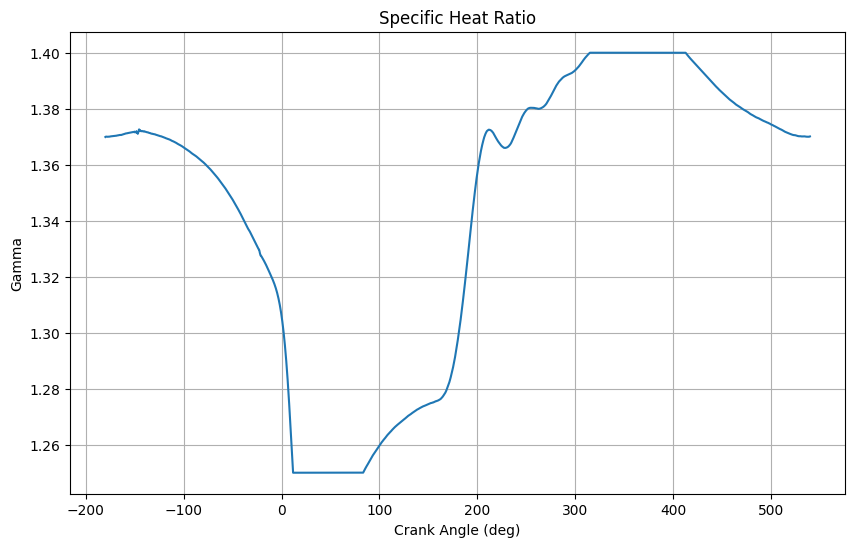

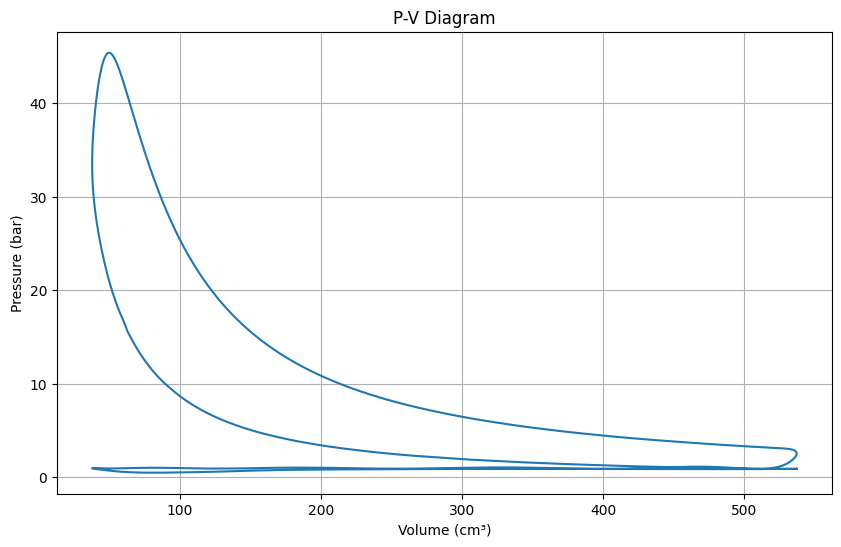

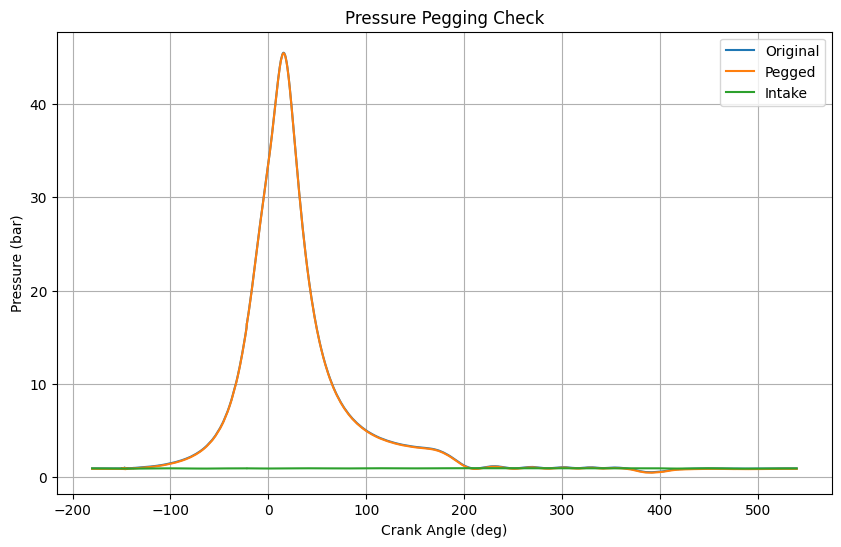

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# ------------------------------------------------
# ENGINE PARAMETERS
# ------------------------------------------------

bore = 0.085
stroke = 0.088
conrod = 0.145
compression_ratio = 14.23

R = 287.0                  # gas constant (J/kg/K)

# ------------------------------------------------
# DERIVED GEOMETRY
# ------------------------------------------------

area = np.pi * (bore/2)**2
r = stroke / 2
l = conrod

Vs = area * stroke
Vc = Vs / (compression_ratio - 1)

# ------------------------------------------------
# CYLINDER VOLUME
# ------------------------------------------------

def cylinder_volume(theta_deg):
    theta = np.radians(theta_deg)
    x = r*(1 - np.cos(theta)) + (l - np.sqrt(l**2 - (r*np.sin(theta))**2))
    V = Vc + area*x
    return V

# ------------------------------------------------
# GAMMA(T) CORRELATION
# ------------------------------------------------

def gamma_temperature(T):
    gamma = 1.38 - 0.0001*(T - 300)
    gamma = np.clip(gamma, 1.25, 1.40)
    return gamma

# ------------------------------------------------
# MASS ESTIMATE AT IVC
# ------------------------------------------------

def estimate_mass(theta, p, V):
    T_ivc = 400.0  # assumed intake temperature (K)
    IVC = -122      # intake valve closing crank angle (deg)
    idx = np.argmin(np.abs(theta - IVC))
    p_ivc = p[idx]
    V_ivc = V[idx]
    m = p_ivc * V_ivc / (R * T_ivc)
    return m

# ------------------------------------------------
# COMBUSTION SOLVER
# ------------------------------------------------

def combustion_solver(theta, p, V):
    m = estimate_mass(theta, p, V)
    gamma = np.ones(len(theta)) * 1.35

    for iteration in range(5):
        dp_dtheta = np.gradient(p, theta)
        dV_dtheta = np.gradient(V, theta)
        HRR = (gamma/(gamma-1))*p*dV_dtheta + (1/(gamma-1))*V*dp_dtheta
        CHR = np.cumsum(HRR * np.gradient(theta))
        Q_total = np.max(CHR)
        xb = CHR / Q_total
        xb = np.clip(xb, 0, 1)
        T = p * V / (m * R)
        gamma = gamma_temperature(T)

    return HRR, CHR, xb, T, gamma

# ------------------------------------------------
# LOAD DATA
# ------------------------------------------------

file_path = "AR_MT_251017_11h31m56s_13542.txt"
data = pd.read_csv(file_path, delim_whitespace=True, comment="#")

theta = data["CAD[deg]"].to_numpy()
p_cyl_bar = data["p_cyl[bar]"].to_numpy()
p_intake_bar = data["p_intake[bar]"].to_numpy()

p_cyl = p_cyl_bar * 1e5
p_intake = p_intake_bar * 1e5

# ------------------------------------------------
# PRESSURE PEGGING
# ------------------------------------------------

peg_window = (theta > -180) & (theta < -122)
p_cyl_mean = np.mean(p_cyl[peg_window])
p_intake_mean = np.mean(p_intake[peg_window])
delta_p = p_intake_mean - p_cyl_mean
print("Applied pressure offset:", delta_p/1e5, "bar")
p_cyl_pegged = p_cyl + delta_p

# ------------------------------------------------
# PRESSURE FILTERING
# ------------------------------------------------

p_filtered = savgol_filter(p_cyl_pegged, 21, 3)

# ------------------------------------------------
# CYLINDER VOLUME
# ------------------------------------------------

V = cylinder_volume(theta)

# ------------------------------------------------
# COMBUSTION ANALYSIS
# ------------------------------------------------

HRR, CHR, xb, T, gamma = combustion_solver(theta, p_filtered, V)
CHR_norm = (CHR - np.min(CHR)) / (np.max(CHR) - np.min(CHR))

# ------------------------------------------------
# COMBUSTION PHASING
# ------------------------------------------------

def find_CA(target):
    idx = np.where(CHR_norm >= target)[0][0]
    return theta[idx]

CA10 = find_CA(0.10)
CA50 = find_CA(0.50)
CA90 = find_CA(0.90)
print("CA10 =", CA10, "deg")
print("CA50 =", CA50, "deg")
print("CA90 =", CA90, "deg")

# ------------------------------------------------
# IMEP
# ------------------------------------------------

work = np.trapz(p_filtered, V)
IMEP = work / Vs
print("IMEP =", IMEP/1e5, "bar")

# ------------------------------------------------
# SAVE RESULTS TO FILE
# ------------------------------------------------

output_data = np.column_stack([theta, p_filtered, gamma, T, HRR, CHR])
header = "CAD[deg] p_filtered[Pa] gamma T[K] HRR[Pa*deg] CHR[Pa*deg]"
np.savetxt("AR_MT_251017_11h31m56s_13542_analysis_results.txt", output_data, header=header, fmt="%.6e", comments='')
print("Analysis results saved to analysis_results.txt")

# ------------------------------------------------
# PLOTS (same as before)
# ------------------------------------------------

plt.figure(figsize=(10,6))
plt.plot(theta, HRR/1000)
plt.xlabel("Crank Angle (deg)")
plt.ylabel("Heat Release Rate (kJ/deg)")
plt.title("Heat Release Rate")
plt.grid()
plt.show()

plt.figure(figsize=(10,6))
plt.plot(theta, CHR_norm, label="MFB")
plt.axvline(CA10, linestyle="--", label="CA10")
plt.axvline(CA50, linestyle="--", label="CA50")
plt.axvline(CA90, linestyle="--", label="CA90")
plt.xlabel("Crank Angle (deg)")
plt.ylabel("Mass Fraction Burned")
plt.title("Combustion Progress")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10,6))
plt.plot(theta, T)
plt.xlabel("Crank Angle (deg)")
plt.ylabel("Temperature (K)")
plt.title("Cylinder Temperature")
plt.grid()
plt.show()

plt.figure(figsize=(10,6))
plt.plot(theta, gamma)
plt.xlabel("Crank Angle (deg)")
plt.ylabel("Gamma")
plt.title("Specific Heat Ratio")
plt.grid()
plt.show()

plt.figure(figsize=(10,6))
plt.plot(V*1e6, p_filtered/1e5)
plt.xlabel("Volume (cm³)")
plt.ylabel("Pressure (bar)")
plt.title("P-V Diagram")
plt.grid()
plt.show()

plt.figure(figsize=(10,6))
plt.plot(theta, p_cyl_bar, label="Original")
plt.plot(theta, p_cyl_pegged/1e5, label="Pegged")
plt.plot(theta, p_intake_bar, label="Intake")
plt.xlabel("Crank Angle (deg)")
plt.ylabel("Pressure (bar)")
plt.title("Pressure Pegging Check")
plt.legend()
plt.grid()
plt.show()